1.  Néstor Camilo Peña Guarín
2.  Luis Carlos Taborda Florez
3.  Sebastian Felipe Vargas Quintero
4.  Eliú Alejandro Barrera Martínez

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
recorridos_iniciales= [
    # --- GRUPO 1: REGISTRO Y EMPRENDIMIENTO (EDIFICA) ---
    ["S1", "S2", "S3", "S4", "S5", "S7"], # El decidido: Lee sobre Edifica y se inscribe con éxito.
    ["S1", "S3", "S4", "S5", "S6"],       # El desafortunado: Intento de inscripción directa con error de red.
    ["S1", "S11", "S12", "S3", "S4", "S5", "S7"], # El cauteloso: Investiga quiénes son antes de registrarse.
    ["S1", "S2", "S19", "S3", "S4", "S5", "S7"], # El social: Mira testimonios en redes y luego se inscribe.
    ["S1", "S31", "S3", "S4", "S5", "S7"], # El analítico: Lee políticas primero y luego se registra.
    ["S1", "S21", "S12", "S3", "S4", "S5", "S6"], # El curioso: Lee noticias, se interesa en Edifica, falla el envío.
    ["S1", "S11", "S2", "S34"], # El indeciso: Mira quiénes son, lee sobre emprender y se va.
    ["S1", "S2", "S8", "S10"], # El proactivo: Ve "Quiero emprender" pero prefiere pedir acompañamiento directo.
    ["S1", "S12", "S13", "S14", "S15", "S17"], # El detallista: Quiere saber más de Edifica antes de inscribirse.
    ["S1", "S3", "S4", "S34"], # El que se arrepiente: Empieza a llenar el formulario y cierra la pestaña.

    # --- GRUPO 2: ESTUDIANTES Y AULA VIRTUAL (TU AULA) ---
    ["S1", "S23", "S24", "S25", "S27"], # El estudiante: Acceso directo y exitoso al aula.
    ["S1", "S23", "S24", "S25", "S26"], # El olvidadizo: Error de credenciales al intentar entrar.
    ["S1", "S23", "S28", "S24", "S25", "S27"], # El recuperador: Restablece contraseña y logra entrar.
    ["S1", "S23", "S24", "S25", "S27", "S30", "S34"], # El aplicado: Entra al aula, va a la biblioteca y sale.
    ["S1", "S23", "S24", "S25", "S27", "S29", "S34"], # El curioso: Entra al aula, revisa quiénes son sus mentores y sale.
    ["S1", "S23", "S24", "S25", "S27", "S23", "S34"], # El que revisa y sale: Entra, verifica algo en el aula y sale.
    ["S1", "S21", "S23", "S24", "S25", "S26"], # El distraído: Lee noticias y luego falla al intentar loguearse.
    ["S1", "S23", "S28", "S34"], # El frustrado: Intenta recuperar contraseña pero se rinde y se va.
    ["S1", "S23", "S24", "S25", "S27", "S31", "S34"], # El normativo: Entra al aula, revisa políticas y sale.
    ["S1", "S22", "S23", "S24", "S25", "S27"], # El fan: Mira los Top Speakers y luego entra a estudiar.

    # --- GRUPO 3: EMPRESAS Y CONTACTO CORPORATIVO ---
    ["S1", "S8", "S10"], # El ejecutivo: Necesita acompañamiento empresarial urgente.
    ["S1", "S8", "S9"], # El ejecutivo con mala suerte: Falla al enviar el correo de solicitud.
    ["S1", "S11", "S13", "S14", "S15", "S17"], # El formal: Lee sobre la fundación y envía formulario de contacto.
    ["S1", "S13", "S14", "S15", "S16"], # El interrumpido: Falla al enviar el formulario de más información.
    ["S1", "S22", "S8", "S10"], # El interesado en charlas: Mira speakers y pide acompañamiento.
    ["S1", "S33", "S13", "S14", "S15", "S17"], # El regional: Viene del portal Latam y contacta a la sede local.
    ["S1", "S18", "S13", "S14", "S15", "S17"], # El inspirado: Ve la misión en acción y decide contactar.
    ["S1", "S11", "S29", "S8", "S10"], # El reclutador: Mira mentores y pide acompañamiento para su empresa.
    ["S1", "S12", "S8", "S10"], # El enfocado: Solo quiere Edifica y apoyo empresarial.
    ["S1", "S13", "S34"], # El que se equivoca de botón: Entra a contacto y se sale.

    # --- GRUPO 4: EXPLORACIÓN DE CONTENIDO Y REDES ---
    ["S1", "S21", "S20", "S19", "S34"], # El explorador: Noticias, directorio, testimonios y sale.
    ["S1", "S20", "S11", "S34"], # El buscador de talento: Mira el directorio de emprendedores y quiénes los avalan.
    ["S1", "S22", "S19", "S34"], # El entusiasta de eventos: Mira los shows y luego los testimonios.
    ["S1", "S18", "S21", "S20", "S34"], # El seguidor: Mira la misión, las noticias y el portafolio.
    ["S1", "S32", "S34"], # El filántropo: Va directo a donar y sale de la página.
    ["S1", "S11", "S31", "S34"], # El legalista: Solo quiere saber quiénes son y sus políticas.
    ["S1", "S33", "S34"], # El viajero: Entra y se va directo al portal de Latinoamérica.
    ["S1", "S20", "S34"], # El breve: Solo le interesa ver el portafolio de emprendedores.
    ["S1", "S19", "S18", "S34"], # El visual: Solo ve testimonios y la misión en acción.
    ["S1", "S21", "S34"], # El lector: Solo entra a ver las noticias del día.

    # --- GRUPO 5: COMPORTAMIENTOS HUMANOS COMPLEJOS ---
    ["S1", "S11", "S18", "S22", "S13", "S14", "S15", "S17"], # El que valida todo: Revisa todo el staff y misión antes de escribir.
    ["S1", "S2", "S12", "S3", "S34"], # El que compara: Lee dos secciones de Edifica y no se decide.
    ["S1", "S23", "S24", "S25", "S27", "S30", "S11", "S34"], # El estudiante que busca staff: Estudia y luego mira quiénes son los jefes.
    ["S1", "S32", "S11", "S19", "S34"], # El donante precavido: Mira dónde donar, pero antes valida la reputación.
    ["S1", "S20", "S8", "S10"], # El aliado comercial: Ve emprendedores y pide acompañamiento para ellos.
    ["S1", "S31", "S32", "S34"], # El transparente: Lee políticas de privacidad antes de donar.
    ["S1", "S21", "S22", "S13", "S14", "S15", "S16"], # El frustrado 2: Mira noticias y shows, pero falla al pedir info.
    ["S1", "S29", "S23", "S24", "S25", "S26"], # El alumno perdido: Busca a su mentor pero no puede entrar al aula.
    ["S1", "S18", "S33", "S34"], # El curioso regional: Mira la misión y se va al portal Latam.
    ["S1", "S2", "S20", "S34"], # El observador: Quiere emprender y mira qué están haciendo otros.

    # --- GRUPO 6: RECORRIDOS RÁPIDOS Y VARIADOS ---
    ["S1", "S12", "S34"], # Salida rápida desde Edifica.
    ["S1", "S19", "S7"], # Error lógico (humano): El usuario intenta forzar un estado de éxito sin flujo (poco común pero pasa).
    ["S1", "S11", "S29", "S34"], # Solo quería conocer a los mentores.
    ["S1", "S22", "S34"], # Solo quería ver los Top Speakers.
    ["S1", "S8", "S10"], # Contacto empresarial directo.
    ["S1", "S23", "S28", "S27"], # Recuperación de contraseña y entrada directa.
    ["S1", "S3", "S4", "S5", "S17"], # Error humano de mezcla de formularios (S5 seguido de S17).
    ["S1", "S13", "S14", "S15", "S16"], # Intento fallido de contacto general.
    ["S1", "S31", "S34"], # Solo consulta de términos y condiciones.
    ["S1", "S21", "S11", "S18", "S34"] # El recorrido institucional completo.
]

In [42]:
recorridos = [
    # --- FOCO: CONVERSIÓN DIRECTA (EDIFICA) ---
    ["S1", "S2", "S3", "S4", "S5", "S7"], # El decidido: Inicio -> Emprender -> Registro -> Éxito.
    ["S1", "S3", "S4", "S5", "S6"],       # Fallo técnico en registro directo.
    ["S1", "S11", "S12", "S3", "S4", "S5", "S7"], # Investigar y luego registrarse.
    ["S1", "S12", "S3", "S4", "S5", "S7"], # Interés directo en Edifica y registro.
    ["S1", "S2", "S3", "S4", "S34"],      # Abandono en medio del formulario.
    ["S1", "S21", "S12", "S3", "S4", "S5", "S6"], # Noticias -> Edifica -> Error.
    ["S1", "S11", "S2", "S34"],           # Conoce al equipo y sale.
    ["S1", "S2", "S8", "S10"],            # Emprender -> Pide acompañamiento -> Éxito.
    ["S1", "S12", "S13", "S14", "S15", "S17"], # Consulta general sobre el programa.
    ["S1", "S2", "S12", "S8", "S10"],     # Interés profundo y contacto.

    # --- FOCO: OPERACIÓN EN EL AULA (TU AULA) ---
    ["S1", "S23", "S24", "S25", "S27"],   # Login exitoso.
    ["S1", "S23", "S24", "S25", "S26"],   # Error de credenciales.
    ["S1", "S23", "S28", "S24", "S25", "S27"], # Recuperación de clave y acceso.
    ["S1", "S23", "S24", "S25", "S27", "S30", "S34"], # Acceso a biblioteca y salida.
    ["S1", "S23", "S24", "S25", "S27", "S29", "S34"], # Consulta de mentores y salida.
    ["S1", "S23", "S24", "S25", "S27", "S23", "S34"], # Revisión rápida de panel.
    ["S1", "S21", "S23", "S24", "S25", "S26"], # Mira noticias e intenta loguearse.
    ["S1", "S23", "S28", "S34"],          # No logra recuperar contraseña y sale.
    ["S1", "S22", "S23", "S24", "S25", "S27"], # Mira speakers y entra a estudiar.
    ["S1", "S11", "S23", "S24", "S25", "S27"], # Mira el staff y entra al aula.

    # --- FOCO: CONTACTO EMPRESARIAL Y SOPORTE ---
    ["S1", "S8", "S10"],                  # Solicitud de acompañamiento directa.
    ["S1", "S8", "S9"],                   # Error en envío de correo.
    ["S1", "S11", "S13", "S14", "S15", "S17"], # Institucional -> Contacto.
    ["S1", "S13", "S14", "S15", "S16"],   # Error en formulario de contacto.
    ["S1", "S22", "S8", "S10"],           # Ve charlas y pide apoyo empresarial.
    ["S1", "S33", "S13", "S14", "S15", "S17"], # Tráfico desde Latam -> Contacto.
    ["S1", "S18", "S13", "S14", "S15", "S17"], # Misión en acción -> Contacto.
    ["S1", "S11", "S29", "S8", "S10"],    # Mentores -> Acompañamiento.
    ["S1", "S12", "S8", "S10"],           # Edifica -> Soporte.
    ["S1", "S13", "S34"],                 # Entra a contacto y sale.

    # --- FOCO: EXPLORACIÓN RÁPIDA (REDUCCIÓN S19, S20, S31) ---
    ["S1", "S21", "S11", "S34"],          # Noticias y quiénes somos.
    ["S1", "S18", "S21", "S34"],          # Misión y noticias.
    ["S1", "S22", "S11", "S34"],          # Speakers y fundadores.
    ["S1", "S18", "S21", "S11", "S34"],   # Recorrido institucional corto.
    ["S1", "S32", "S34"],                 # Donación directa.
    ["S1", "S11", "S34"],                 # Solo conócenos.
    ["S1", "S33", "S34"],                 # Salida a Portal Latam.
    ["S1", "S2", "S12", "S34"],           # Mira programa y sale.
    ["S1", "S18", "S34"],                 # Mira misión y sale.
    ["S1", "S21", "S34"],                 # Solo noticias.

    # --- FOCO: RECORRIDOS MIXTOS ---
    ["S1", "S11", "S18", "S22", "S13", "S14", "S15", "S17"],
    ["S1", "S2", "S12", "S3", "S34"],
    ["S1", "S23", "S24", "S25", "S27", "S30", "S11", "S34"],
    ["S1", "S32", "S11", "S34"],
    ["S1", "S11", "S8", "S10"],
    ["S1", "S21", "S22", "S13", "S14", "S15", "S16"],
    ["S1", "S29", "S23", "S24", "S25", "S26"],
    ["S1", "S18", "S33", "S34"],
    ["S1", "S12", "S11", "S34"],
    ["S1", "S21", "S11", "S29", "S34"],

    # --- FOCO: CIERRES RÁPIDOS ---
    ["S1", "S12", "S34"],
    ["S1", "S11", "S29", "S34"],
    ["S1", "S22", "S34"],
    ["S1", "S8", "S10"],
    ["S1", "S23", "S28", "S27"],
    ["S1", "S3", "S4", "S34"],
    ["S1", "S13", "S14", "S15", "S16"],
    ["S1", "S32", "S11", "S34"],
    ["S1", "S21", "S11", "S18", "S34"],
    ["S1", "S2", "S34"]
]

In [43]:
estados = [
    "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8", "S9", "S10",
    "S11", "S12", "S13", "S14", "S15", "S16", "S17", "S18", "S19", "S20",
    "S21", "S22", "S23", "S24", "S25", "S26", "S27", "S28", "S29", "S30",
    "S31", "S32", "S33", "S34"
]

In [44]:
# Crear matriz inicializada en cero
matriz_conteos = pd.DataFrame(0, index=estados, columns=estados)

# Recorrer todos los recorridos y contar transiciones
for recorrido in recorridos:
    for i in range(len(recorrido) - 1):
        estado_actual   = recorrido[i]
        estado_siguiente = recorrido[i + 1]
        matriz_conteos.loc[estado_actual, estado_siguiente] += 1

matriz_conteos


,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,...,S25,S26,S27,S28,S29,S30,S31,S32,S33,S34
S1,0,7,2,0,0,0,0,3,0,0,...,0,0,0,0,1,0,0,3,2,0
S2,0,0,2,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,2
S3,0,0,0,7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
S4,0,0,0,0,5,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
S5,0,0,0,0,0,2,3,0,0,0,...,0,0,0,0,0,0,0,0,0,0
S6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
S7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
S8,0,0,0,0,0,0,0,0,1,8,...,0,0,0,0,0,0,0,0,0,0
S9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
S10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [45]:
# Dividir cada fila entre su total para obtener probabilidades
matriz_probabilidades = matriz_conteos.div(
    matriz_conteos.sum(axis=1),  # suma por filas
    axis=0                        # aplicar división por filas
).fillna(0)                       # estados sin salidas → 0

matriz_probabilidades


,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,...,S25,S26,S27,S28,S29,S30,S31,S32,S33,S34
S1,0.0,0.116667,0.033333,0.000,0.000000,0.0,0.0,0.050000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.016667,0.0,0.0,0.05,0.033333,0.000000
S2,0.0,0.000000,0.250000,0.000,0.000000,0.0,0.0,0.125000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00,0.000000,0.250000
S3,0.0,0.000000,0.000000,0.875,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00,0.000000,0.125000
S4,0.0,0.000000,0.000000,0.000,0.714286,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00,0.000000,0.285714
S5,0.0,0.000000,0.000000,0.000,0.000000,0.4,0.6,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00,0.000000,0.000000
S6,0.0,0.000000,0.000000,0.000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00,0.000000,0.000000
S7,0.0,0.000000,0.000000,0.000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00,0.000000,0.000000
S8,0.0,0.000000,0.000000,0.000,0.000000,0.0,0.0,0.000000,0.111111,0.888889,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00,0.000000,0.000000
S9,0.0,0.000000,0.000000,0.000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00,0.000000,0.000000
S10,0.0,0.000000,0.000000,0.000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00,0.000000,0.000000


In [46]:
def simular_usuario(matriz_probabilidades, estado_inicial='S1', max_pasos=15):
    estado_actual = estado_inicial
    recorrido     = [estado_actual]
    estados_finales = ["S6", "S7", "S9", "S10", "S16", "S17", "S26", "S27", "S34"]

    for _ in range(max_pasos):
        if estado_actual in estados_finales:
            break                                 # detener si llegó al final

        probabilidades = matriz_probabilidades.loc[estado_actual]

        if probabilidades.sum() == 0:
            break                                 # sin transiciones posibles

        siguiente_estado = np.random.choice(
            matriz_probabilidades.columns,        # lista de estados
            p=probabilidades.values               # pesos de probabilidad
        )
        recorrido.append(siguiente_estado)
        estado_actual = siguiente_estado

    return recorrido


In [47]:
# Simular un usuario
recorrido_simulado = simular_usuario(matriz_probabilidades)

# Mostrar el recorrido
print(" → ".join(recorrido_simulado))


S1 → S22 → S23 → S34


In [48]:
resultados = []

for i in range(1000):
    recorrido   = simular_usuario(matriz_probabilidades)
    estado_final = recorrido[-1]

    resultados.append({
        "usuario":      i + 1,
        "recorrido":    " → ".join(recorrido),
        "estado_final": estado_final,
        "num_pasos":    len(recorrido)
    })

df_resultados = pd.DataFrame(resultados)
df_resultados.head()


,usuario,recorrido,estado_final,num_pasos
0,1,S1 → S23 → S24 → S25 → S27,S27,5
1,2,S1 → S33 → S34,S34,3
2,3,S1 → S29 → S23 → S24 → S25 → S27,S27,6
3,4,S1 → S22 → S8 → S10,S10,4
4,5,S1 → S11 → S8 → S10,S10,4


In [49]:
nombres_estados = {
    "S1": "INICIO",
    "S2": "QUIERO EMPRENDER",
    "S3": "INSCRÍBETE",
    "S4": "LLENAR FORMULARIO DE INSCRIPCIÓN",
    "S5": "ENVIAR FORMULARIO DE INSCRIPCIÓN",
    "S6": "ERROR AL ENVIAR FORMULARIO DE INSCRIPCIÓN",
    "S7": "ÉXITO AL ENVIAR FORMULARIO DE INSCRIPCIÓN",
    "S8": "QUIERO CONOCER MÁS INFORMACIÓN",
    "S9": "ERROR AL ENVIAR CORREO DE MÁS INFO",
    "S10": "ÉXITO AL ENVIAR CORREO DE MÁS INFO",
    "S11": "CONÓCENOS",
    "S12": "PROGRAMA EDIFICA",
    "S13": "CONTÁCTENOS",
    "S14": "LLENAR FORMULARIO DE MÁS INFORMACIÓN",
    "S15": "ENVIAR FORMULARIO DE MÁS INFORMACIÓN",
    "S16": "ERROR AL ENVIAR FORMULARIO DE MÁS INFORMACIÓN",
    "S17": "ÉXITO AL ENVIAR FORMULARIO DE MÁS INFORMACIÓN",
    "S18": "NUESTRA MISIÓN EN ACCIÓN",
    "S19": "VER TESTIMONIOS",
    "S20": "DIRECTORIO DE EMPRENDEDORES",
    "S21": "NOTICIAS",
    "S22": "TOP SPEAKERS",
    "S23": "TU AULA",
    "S24": "LLENAR CREDENCIALES DE INGRESO AL PROGRAMA EDIFICA",
    "S25": "ENVIAR CREDENCIALES",
    "S26": "ERROR DE CREDENCIALES",
    "S27": "ÉXITO DE INGRESO A TU AULA",
    "S28": "REESTABLECER CONTRASEÑA",
    "S29": "MENTORES",
    "S30": "BIBLIOTECA",
    "S31": "POLÍTICAS",
    "S32": "DONACIONES <3",
    "S33": "PORTAL LATINOAMÉRICA COMPARTE",
    "S34": "SALIR"
}

df_resultados["resultado"] = df_resultados["estado_final"].map(nombres_estados)
df_resultados.head()


,usuario,recorrido,estado_final,num_pasos,resultado
0,1,S1 → S23 → S24 → S25 → S27,S27,5,ÉXITO DE INGRESO A TU AULA
1,2,S1 → S33 → S34,S34,3,SALIR
2,3,S1 → S29 → S23 → S24 → S25 → S27,S27,6,ÉXITO DE INGRESO A TU AULA
3,4,S1 → S22 → S8 → S10,S10,4,ÉXITO AL ENVIAR CORREO DE MÁS INFO
4,5,S1 → S11 → S8 → S10,S10,4,ÉXITO AL ENVIAR CORREO DE MÁS INFO


In [50]:
# Frecuencia relativa de cada resultado final (en %)
porcentajes = df_resultados["resultado"].value_counts(normalize=True) * 100

print(porcentajes.round(1))


resultado
SALIR                                            43.0
ÉXITO AL ENVIAR CORREO DE MÁS INFO               15.2
ÉXITO DE INGRESO A TU AULA                       14.7
ÉXITO AL ENVIAR FORMULARIO DE MÁS INFORMACIÓN     8.9
ÉXITO AL ENVIAR FORMULARIO DE INSCRIPCIÓN         5.1
ERROR DE CREDENCIALES                             4.8
ERROR AL ENVIAR FORMULARIO DE MÁS INFORMACIÓN     4.3
ERROR AL ENVIAR FORMULARIO DE INSCRIPCIÓN         2.7
ERROR AL ENVIAR CORREO DE MÁS INFO                1.3
Name: proportion, dtype: float64


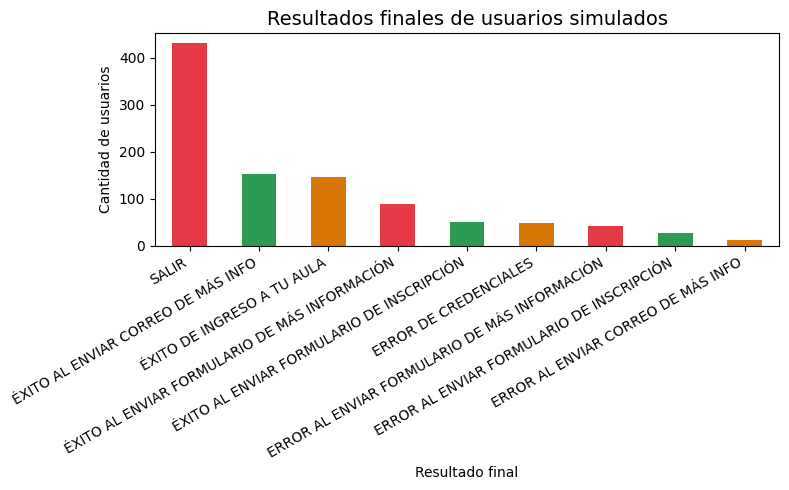

In [51]:
conteo = df_resultados["resultado"].value_counts()

plt.figure(figsize=(8, 5))
conteo.plot(kind='bar', color=['#E63946', '#2D9B51', '#D97706'])
plt.title('Resultados finales de usuarios simulados', fontsize=14)
plt.xlabel('Resultado final')
plt.ylabel('Cantidad de usuarios')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


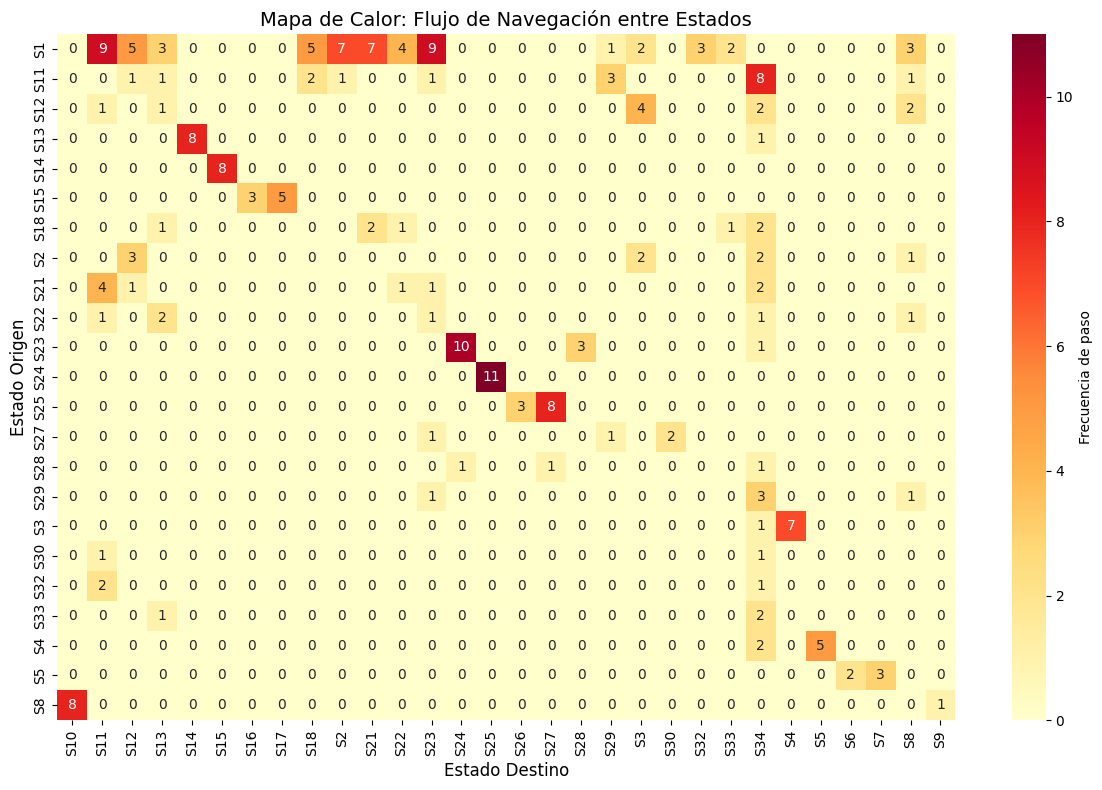

In [52]:
transiciones = []
for camino in recorridos:
    for i in range(len(camino) - 1):
        transiciones.append((camino[i], camino[i+1]))

df_trans = pd.DataFrame(transiciones, columns=['Origen', 'Destino'])
matriz_calor = pd.crosstab(df_trans['Origen'], df_trans['Destino'])

plt.figure(figsize=(12, 8))
sns.heatmap(matriz_calor, annot=True, cmap="YlOrRd", fmt='d', cbar_kws={'label': 'Frecuencia de paso'})

plt.title('Mapa de Calor: Flujo de Navegación entre Estados', fontsize=14)
plt.xlabel('Estado Destino', fontsize=12)
plt.ylabel('Estado Origen', fontsize=12)
plt.tight_layout()
plt.show()